3. Forecast Data Visualizer (Animated Chart)

C:\Users\rchms\AppData\Local\Temp\ipykernel_2944\431818258.py:7: ParserWarning: Skipping line 3: expected 7 fields, saw 13
Skipping line 4: expected 7 fields, saw 13
Skipping line 5: expected 7 fields, saw 13

  df = pd.read_csv("weather_data.csv", on_bad_lines='warn')


Saved as forecast_plot.gif


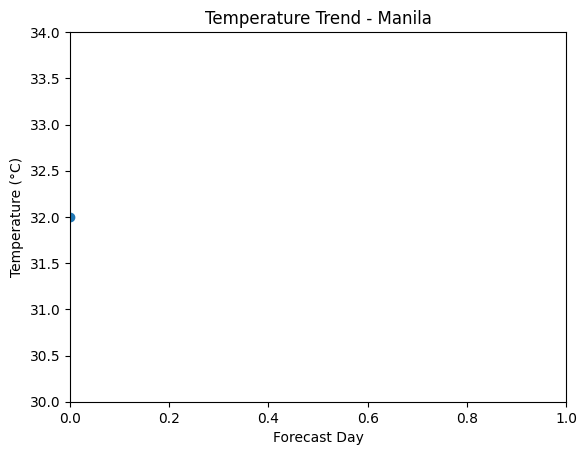

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation

city = input("Enter city name: ").strip().lower()

df = pd.read_csv("weather_data.csv", on_bad_lines='warn')

# normalize city column
df["city"] = df["city"].astype(str).str.lower().str.strip()

city_df = df[df["city"].str.contains(city)]

if city_df.empty:
    print("No data found for city.")
else:
    # clean temperature values (extract numbers only)
    temps = city_df["temperature"].astype(str).str.extract(r"(\d+)")[0].astype(float).values

    x = list(range(len(temps)))

    fig, ax = plt.subplots()

    ax.set_title(f"Temperature Trend - {city.title()}")
    ax.set_xlabel("Forecast Day")
    ax.set_ylabel("Temperature (°C)")

    line, = ax.plot([], [], marker="o")

    def update(frame):
        line.set_data(x[:frame], temps[:frame])
        ax.set_xlim(0, len(temps))
        ax.set_ylim(min(temps) - 2, max(temps) + 2)
        return line,

    ani = animation.FuncAnimation(fig, update, frames=len(temps) + 1, interval=800)

    # SAVE GIF OUTPUT
    ani.save("forecast_plot.gif", writer="pillow")

    print("Saved as forecast_plot.gif")
    plt.show()